# SAR Data Preprocessing Analysis
***
In this notebook, I visualize and plot the histograms of one TerraSAR-X tile (of Hamburg) during the different stages of pre-processing.

The visualization is not done on the complete tile but on a 1024x1024 patch in the city-center. However, the histograms show the data of the whole tile.

## Processing Steps:
1. **Raw Data**: Original CoSAR format data
2. **After Symmetrization**: Zero-Doppler centered and symmetrized
3. **After Normalization**: Squaring and Log-scale normalization

*NOTE: Because we don't see much at steps 1 and 2, I also show the images in log-scale. To do so I take the absolute value of the Real and Imaginary components to avoid logarithm of negative values)*

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add project root to path
sys.path.append(str(Path().resolve().parent))

from src.utils.sar_utils import load_cosar, symmetrize
from src.utils.constants import amp_max, amp_min

# Configuration
IMAGE_PATH = Path(
    "../data/TSX_cos_files/Hamburg_TDX1_SAR__SSC______SM_S_SRA_20180112T165337_20180112T165345_IMAGE_HH_SRA_strip_004.cos"
)
CROP_COORDINATES = (11000, 8500)  # Hamburg: ncolumns=14686 nlines=32901
PATCH_SIZE = (1024, 1024)
epsilon = 1e-2  # For log scales

# Set up matplotlib
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 10

print(f"Image path: {IMAGE_PATH}, Image exists: {IMAGE_PATH.exists()}")
print(f"Crop coordinates: {CROP_COORDINATES}. Patch size: {PATCH_SIZE}")

Image path: ../data/TSX_cos_files/Hamburg_TDX1_SAR__SSC______SM_S_SRA_20180112T165337_20180112T165345_IMAGE_HH_SRA_strip_004.cos, Image exists: True
Crop coordinates: (11000, 8500). Patch size: (1024, 1024)


In [2]:
def plot_image_components(
    images: list[np.ndarray],
    titles: list[str],
    figsize: tuple[int, int] = (15, 5),
):
    """Visualize a list of images as a subplot (1 row, len(image) columns)."""
    if len(images) != len(titles):
        raise ValueError("Number of images must match number of titles.")

    fig, axes = plt.subplots(1, len(images), figsize=figsize)

    for ax, img, title in zip(axes, images, titles):
        im = ax.imshow(img, cmap="gray", aspect="equal")
        ax.set_title(title)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


def plot_histograms(
    images: list[np.ndarray],
    titles: list[str],
    bins: int = 100,
    figsize: tuple[int, int] = (15, 5),
):
    """Plot histograms of a list of images as a subplot (1 row, len(images) columns)."""
    if len(images) != len(titles):
        raise ValueError("Number of images must match number of titles.")
    fig, axes = plt.subplots(1, len(images), figsize=figsize)

    for ax, img, title in zip(axes, images, titles):
        ax.hist(img.flatten(), bins=bins, alpha=0.7, color="blue")
        ax.set_title(title)
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
        ax.grid(True, alpha=0.3)

        # Add a red line for the mean of image and 2 dotted green lines for mean - 3*std and mean + 3*std
        mean = img.mean()
        std = img.std()
        ax.axvline(
            mean,
            color="red",
            linestyle="solid",
            linewidth=1.5,
            label=f"Mean={mean:.3f}",
        )
        ax.axvline(
            mean - 3 * std,
            color="green",
            linestyle="dotted",
            linewidth=1.5,
            label=f"-3 Std={mean - 3 * std:.3f}",
        )
        ax.axvline(
            mean + 3 * std,
            color="green",
            linestyle="dotted",
            linewidth=1.5,
            label=f"+3 Std={mean + 3 * std:.3f}",
        )
        ax.legend()

    plt.tight_layout()
    plt.show()


def print_statistics(image: np.ndarray, title_prefix: str):
    """Print statistics of real and imaginary components."""

    print(f"{title_prefix} Statistics (Shape: {image.shape})")
    print(
        f"  Real Component - min: {image[:, :, 0].min():.4f}, max: {image[:, :, 0].max():.4f}, mean: {image[:, :, 0].mean():.4f}, std: {image[:, :, 0].std():.4f}"
    )
    print(
        f"  Imaginary Component - min: {image[:, :, 1].min():.4f}, max: {image[:, :, 1].max():.4f}, mean: {image[:, :, 1].mean():.4f}, std: {image[:, :, 1].std():.4f}"
    )
    print("\n")

## Step 1: Load Raw CoSAR Data
***
First, we load the raw SAR data from the CoSAR file. This gives us the SLC SAR image with real and imaginary components.

Loading raw CoSAR data...
Raw Data Statistics (Shape: (32901, 14686, 2))
  Real Component - min: -32767.0000, max: 32767.0000, mean: 0.0166, std: 191.3194
  Imaginary Component - min: -32767.0000, max: 32767.0000, mean: 0.0061, std: 191.5409




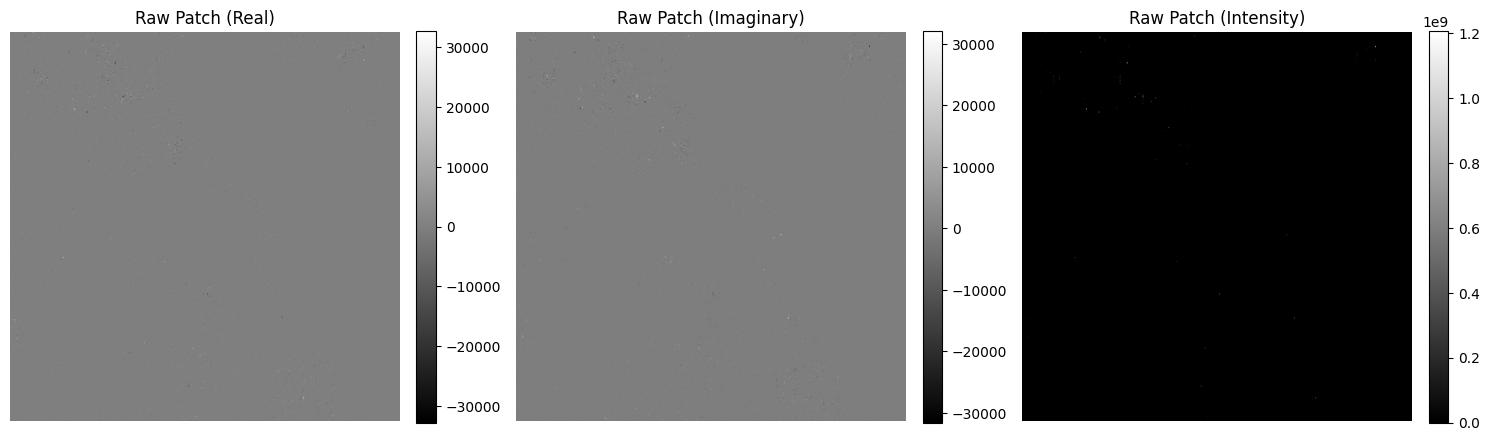

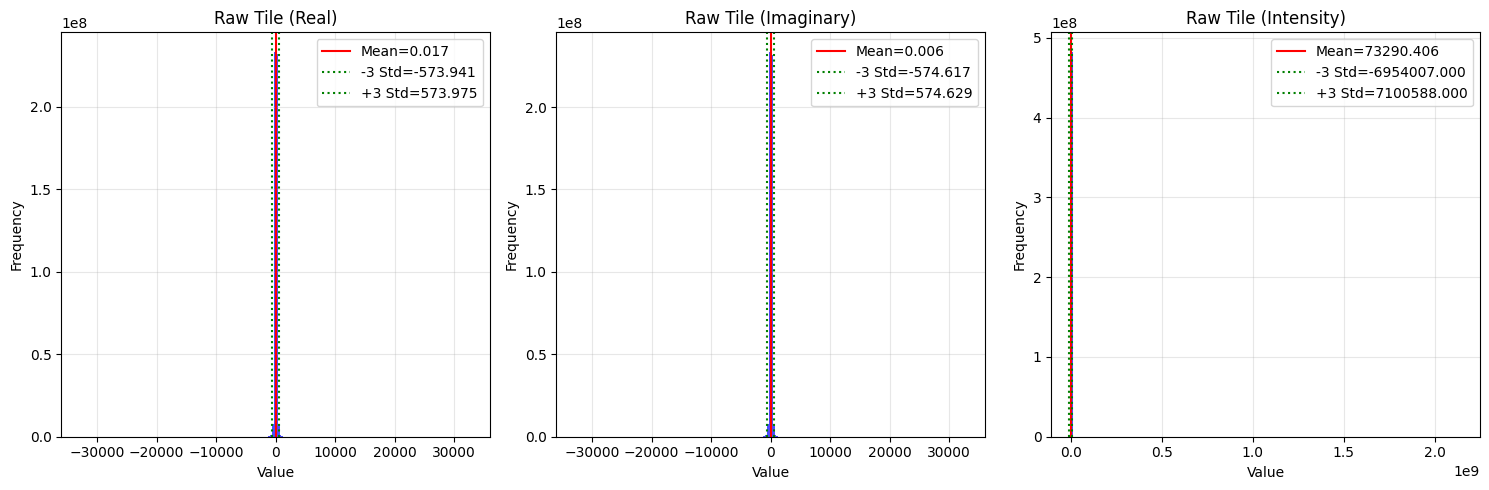

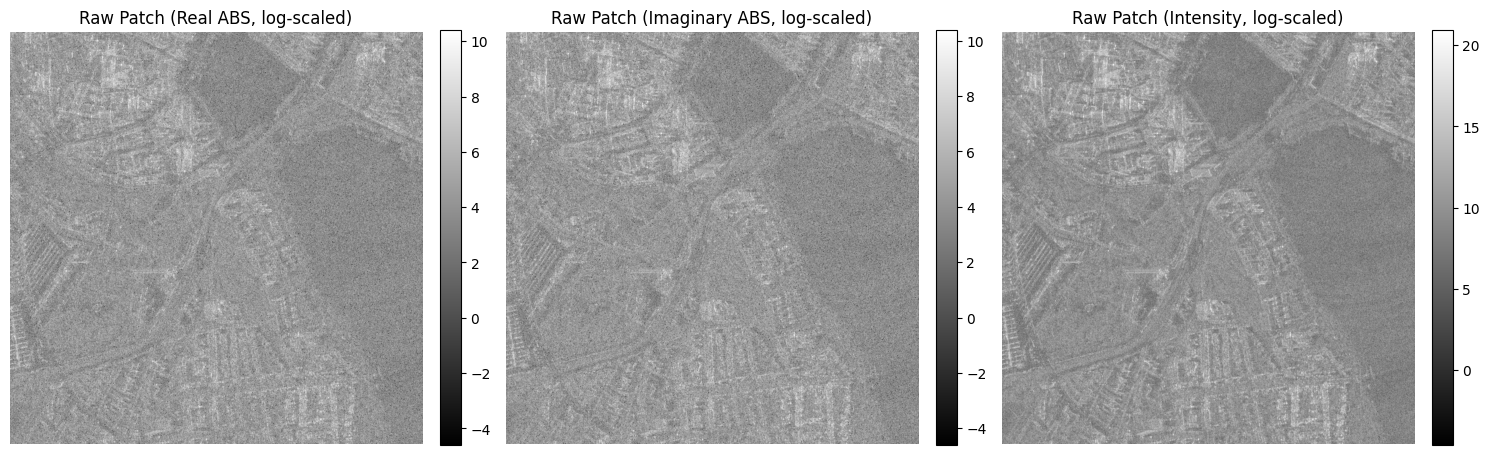

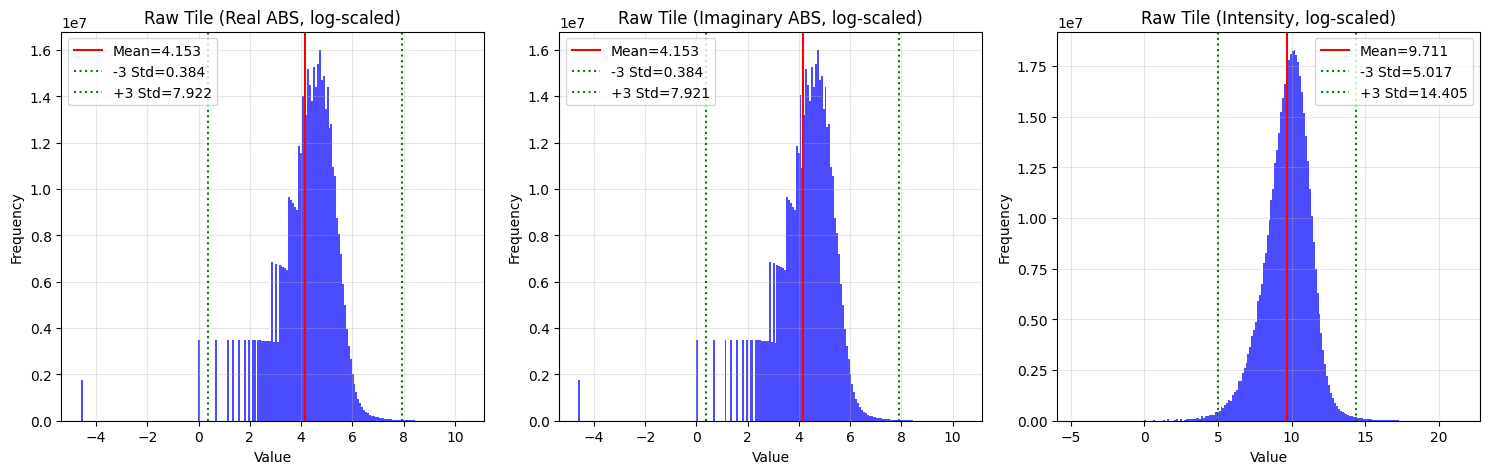

In [3]:
# Load raw CoSAR data
print("Loading raw CoSAR data...")
raw_image = load_cosar(IMAGE_PATH, logger=None)
if raw_image is None:
    raise ValueError(f"Failed to load image from {IMAGE_PATH}")

print_statistics(raw_image, "Raw Data")

# Extract the patch for visualization
raw_patch = raw_image[
    CROP_COORDINATES[0] : CROP_COORDINATES[0] + PATCH_SIZE[0],
    CROP_COORDINATES[1] : CROP_COORDINATES[1] + PATCH_SIZE[1],
    :,
]

# ------------------------------ RAW DATA ------------------------------
# Visualize the raw data patch
plot_image_components(
    [
        raw_patch[:, :, 0],
        raw_patch[:, :, 1],
        np.square(raw_patch[:, :, 0]) + np.square(raw_patch[:, :, 1]),
    ],
    ["Raw Patch (Real)", "Raw Patch (Imaginary)", "Raw Patch (Intensity)"],
)

# Plot histograms of the full image
plot_histograms(
    [
        raw_image[:, :, 0],
        raw_image[:, :, 1],
        np.square(raw_image[:, :, 0]) + np.square(raw_image[:, :, 1]),
    ],
    ["Raw Tile (Real)", "Raw Tile (Imaginary)", "Raw Tile (Intensity)"],
    bins=200,
)

# ------------------------------ RAW DATA (ABS and Log-Scaled) ------------------------------
# Visualize the raw data patch
plot_image_components(
    [
        np.log(np.abs(raw_patch[:, :, 0]) + epsilon),
        np.log(np.abs(raw_patch[:, :, 1]) + epsilon),
        np.log(np.square(raw_patch[:, :, 0]) + np.square(raw_patch[:, :, 1]) + epsilon),
    ],
    [
        "Raw Patch (Real ABS, log-scaled)",
        "Raw Patch (Imaginary ABS, log-scaled)",
        "Raw Patch (Intensity, log-scaled)",
    ],
)

# Plot histograms of the full image
plot_histograms(
    [
        np.log(np.abs(raw_image[:, :, 0]) + epsilon),
        np.log(np.abs(raw_image[:, :, 1]) + epsilon),
        np.log(np.square(raw_image[:, :, 0]) + np.square(raw_image[:, :, 1]) + epsilon),
    ],
    [
        "Raw Tile (Real ABS, log-scaled)",
        "Raw Tile (Imaginary ABS, log-scaled)",
        "Raw Tile (Intensity, log-scaled)",
    ],
    bins=200,
)

## Step 2: Apply Symmetrization
***
We symmetrize the image to ensure the Real and Imaginary components are i.i.d. and allow correct self-supervised learning training.

Applying symmetrization to full tile...
Symmetrized Data Statistics (Shape: (32901, 14686, 2))
  Real Component - min: -45928.9570, max: 44061.8672, mean: 0.0436, std: 191.4028
  Imaginary Component - min: -44694.6289, max: 41798.7461, mean: 0.0204, std: 191.4571




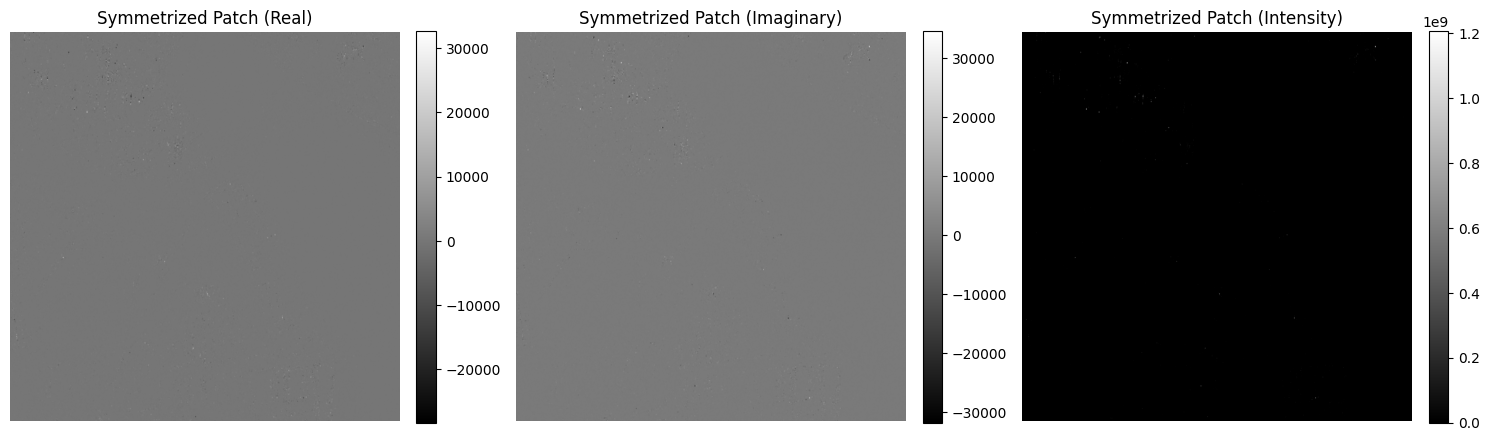

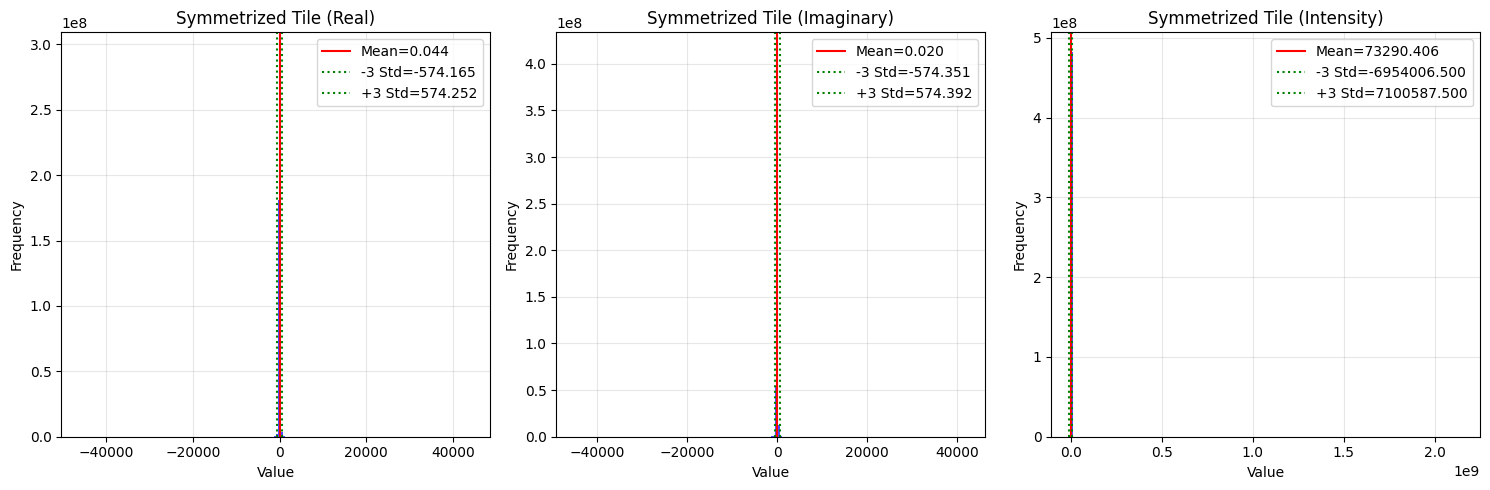

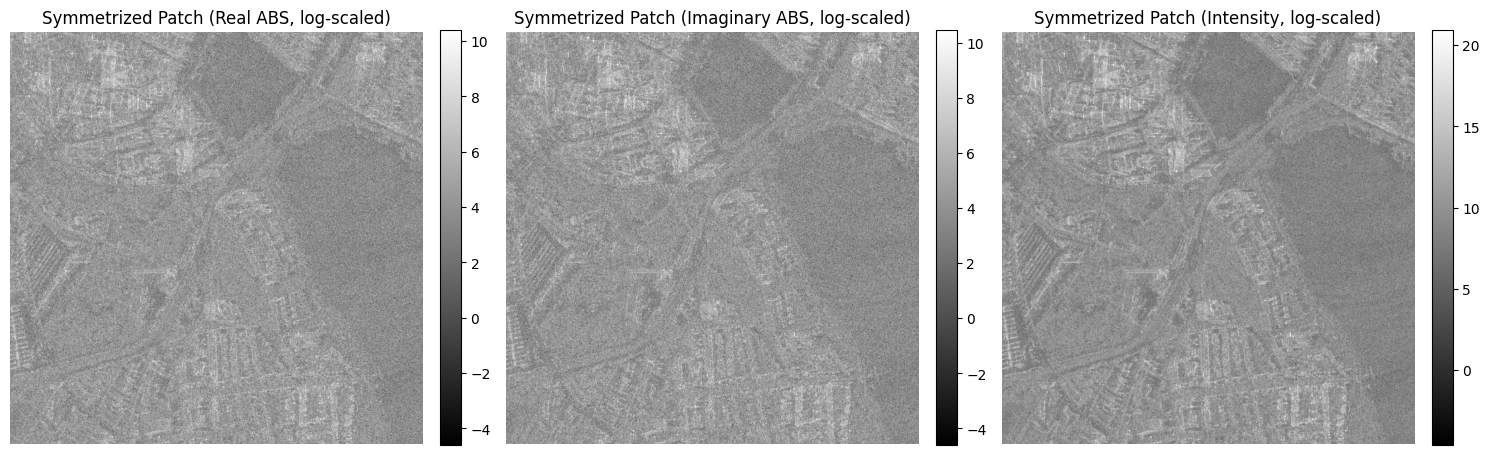

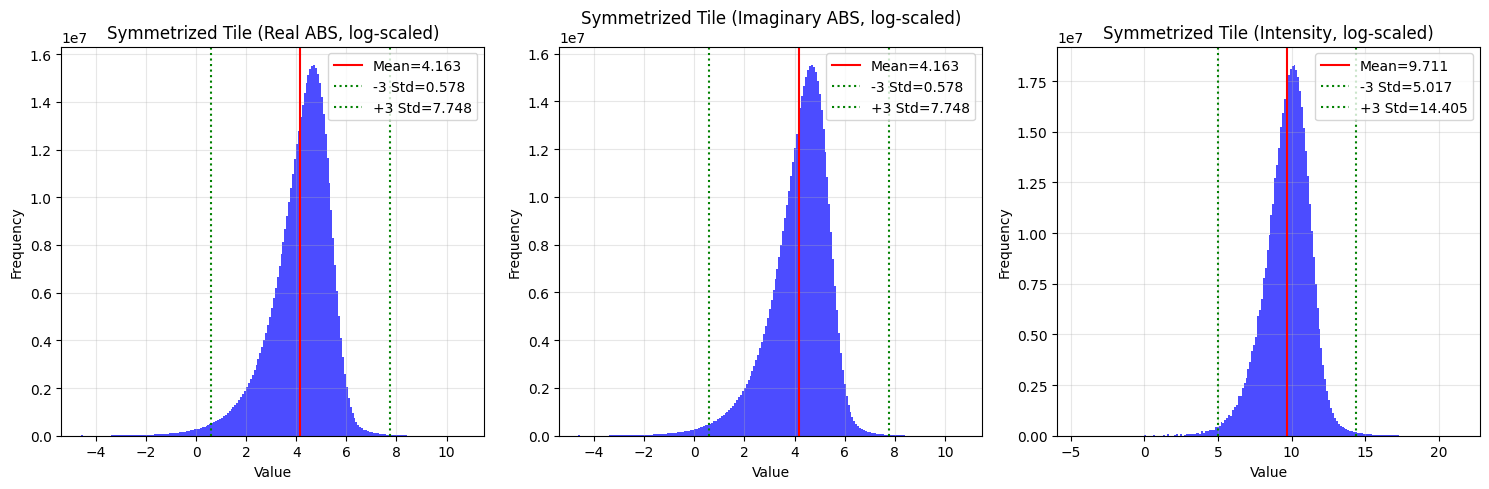

In [4]:
# Apply symmetrization to the full tile
print("Applying symmetrization to full tile...")
symmetrized_image = symmetrize(raw_image)

print_statistics(symmetrized_image, "Symmetrized Data")

# Extract the same patch for visualization
symmetrized_patch = symmetrized_image[
    CROP_COORDINATES[0] : CROP_COORDINATES[0] + PATCH_SIZE[0],
    CROP_COORDINATES[1] : CROP_COORDINATES[1] + PATCH_SIZE[1],
    :,
]

# ------------------------------ SYMMETRIZED DATA ------------------------------
# Visualize the raw data patch
plot_image_components(
    [
        symmetrized_patch[:, :, 0],
        symmetrized_patch[:, :, 1],
        np.square(symmetrized_patch[:, :, 0]) + np.square(symmetrized_patch[:, :, 1]),
    ],
    [
        "Symmetrized Patch (Real)",
        "Symmetrized Patch (Imaginary)",
        "Symmetrized Patch (Intensity)",
    ],
)

# Plot histograms of the full tile
plot_histograms(
    [
        symmetrized_image[:, :, 0],
        symmetrized_image[:, :, 1],
        np.square(symmetrized_image[:, :, 0]) + np.square(symmetrized_image[:, :, 1]),
    ],
    [
        "Symmetrized Tile (Real)",
        "Symmetrized Tile (Imaginary)",
        "Symmetrized Tile (Intensity)",
    ],
    bins=200,
)

# ------------------------------ SYMMETRIZED DATA (Absolute value and Log-Scaled) ------------------------------
# Visualize the raw data patch
plot_image_components(
    [
        np.log(np.abs(symmetrized_patch[:, :, 0]) + epsilon),
        np.log(np.abs(symmetrized_patch[:, :, 1]) + epsilon),
        np.log(
            np.square(symmetrized_patch[:, :, 0])
            + np.square(symmetrized_patch[:, :, 1])
            + epsilon
        ),
    ],
    [
        "Symmetrized Patch (Real ABS, log-scaled)",
        "Symmetrized Patch (Imaginary ABS, log-scaled)",
        "Symmetrized Patch (Intensity, log-scaled)",
    ],
)

# Plot histograms of the full tile
plot_histograms(
    [
        np.log(np.abs(symmetrized_image[:, :, 0]) + epsilon),
        np.log(np.abs(symmetrized_image[:, :, 1]) + epsilon),
        np.log(
            np.square(symmetrized_image[:, :, 0])
            + np.square(symmetrized_image[:, :, 1])
            + epsilon
        ),
    ],
    [
        "Symmetrized Tile (Real ABS, log-scaled)",
        "Symmetrized Tile (Imaginary ABS, log-scaled)",
        "Symmetrized Tile (Intensity, log-scaled)",
    ],
    bins=200,
)

## Step 3: Square and apply Normalization
***
Finally, we apply the same normalization that is used in the dataset's `__getitem__` method. This includes:
1. Squaring the Real and Imaginary parts
1. Taking the logarithm `log(x + epsilon)`
2. Applying min-max normalization using the predefined constants from the dataset `amp_min` and `amp_max` (`m` and `M` in MERLIN)

Applying squaring, log-scale, and normalization...
Using amp_min = -4.605170249938965, amp_max = 10.742239952087402.
Normalized Data Statistics (Shape: (32901, 14686, 2))
  Real Component - min: 0.1500, max: 0.9995, mean: 0.5714, std: 0.0776
  Imaginary Component - min: 0.1500, max: 0.9977, mean: 0.5714, std: 0.0776




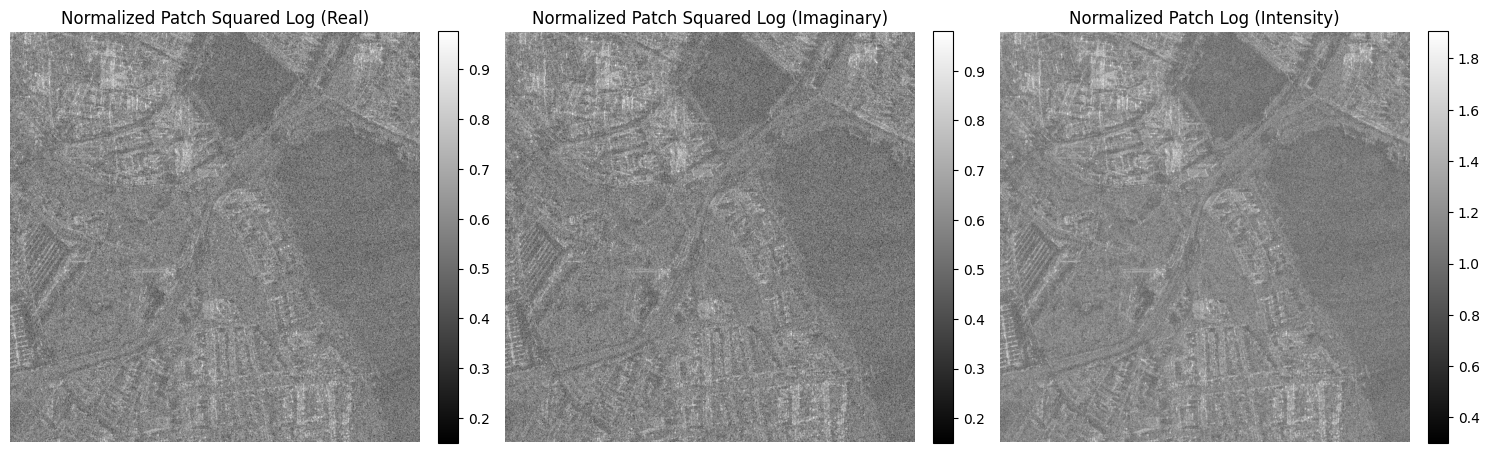

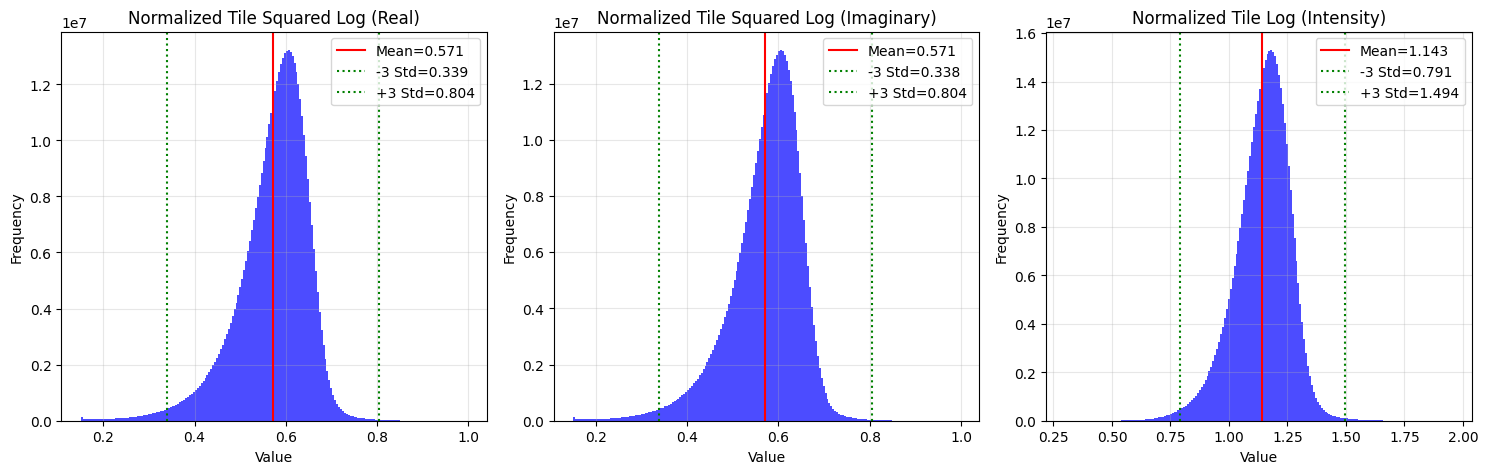

In [5]:
# Apply the final normalization (same as in dataset __getitem__)
print("Applying squaring, log-scale, and normalization...")
print(f"Using amp_min = {amp_min}, amp_max = {amp_max}.")

squared_image = np.square(symmetrized_image)
log_image = np.log(squared_image + 1e-2)
normalized_image = (log_image - 2 * amp_min) / (2 * amp_max - 2 * amp_min)

print_statistics(normalized_image, "Normalized Data")

# Extract the same patch for visualization
normalized_patch = normalized_image[
    CROP_COORDINATES[0] : CROP_COORDINATES[0] + PATCH_SIZE[0],
    CROP_COORDINATES[1] : CROP_COORDINATES[1] + PATCH_SIZE[1],
    :,
]

# ------------------------------ NORMALIZED DATA ------------------------------
# Visualize the raw data patch
plot_image_components(
    [
        normalized_patch[:, :, 0],
        normalized_patch[:, :, 1],
        normalized_patch[:, :, 0] + normalized_patch[:, :, 1],
    ],
    [
        "Normalized Patch Squared Log (Real)",
        "Normalized Patch Squared Log (Imaginary)",
        "Normalized Patch Log (Intensity)",
    ],
)

# Plot histograms of the full image
plot_histograms(
    [
        normalized_image[:, :, 0],
        normalized_image[:, :, 1],
        normalized_image[:, :, 0] + normalized_image[:, :, 1],
    ],
    [
        "Normalized Tile Squared Log (Real)",
        "Normalized Tile Squared Log (Imaginary)",
        "Normalized Tile Log (Intensity)",
    ],
    bins=200,
)

## Summary: Side-by-Side Comparison
***

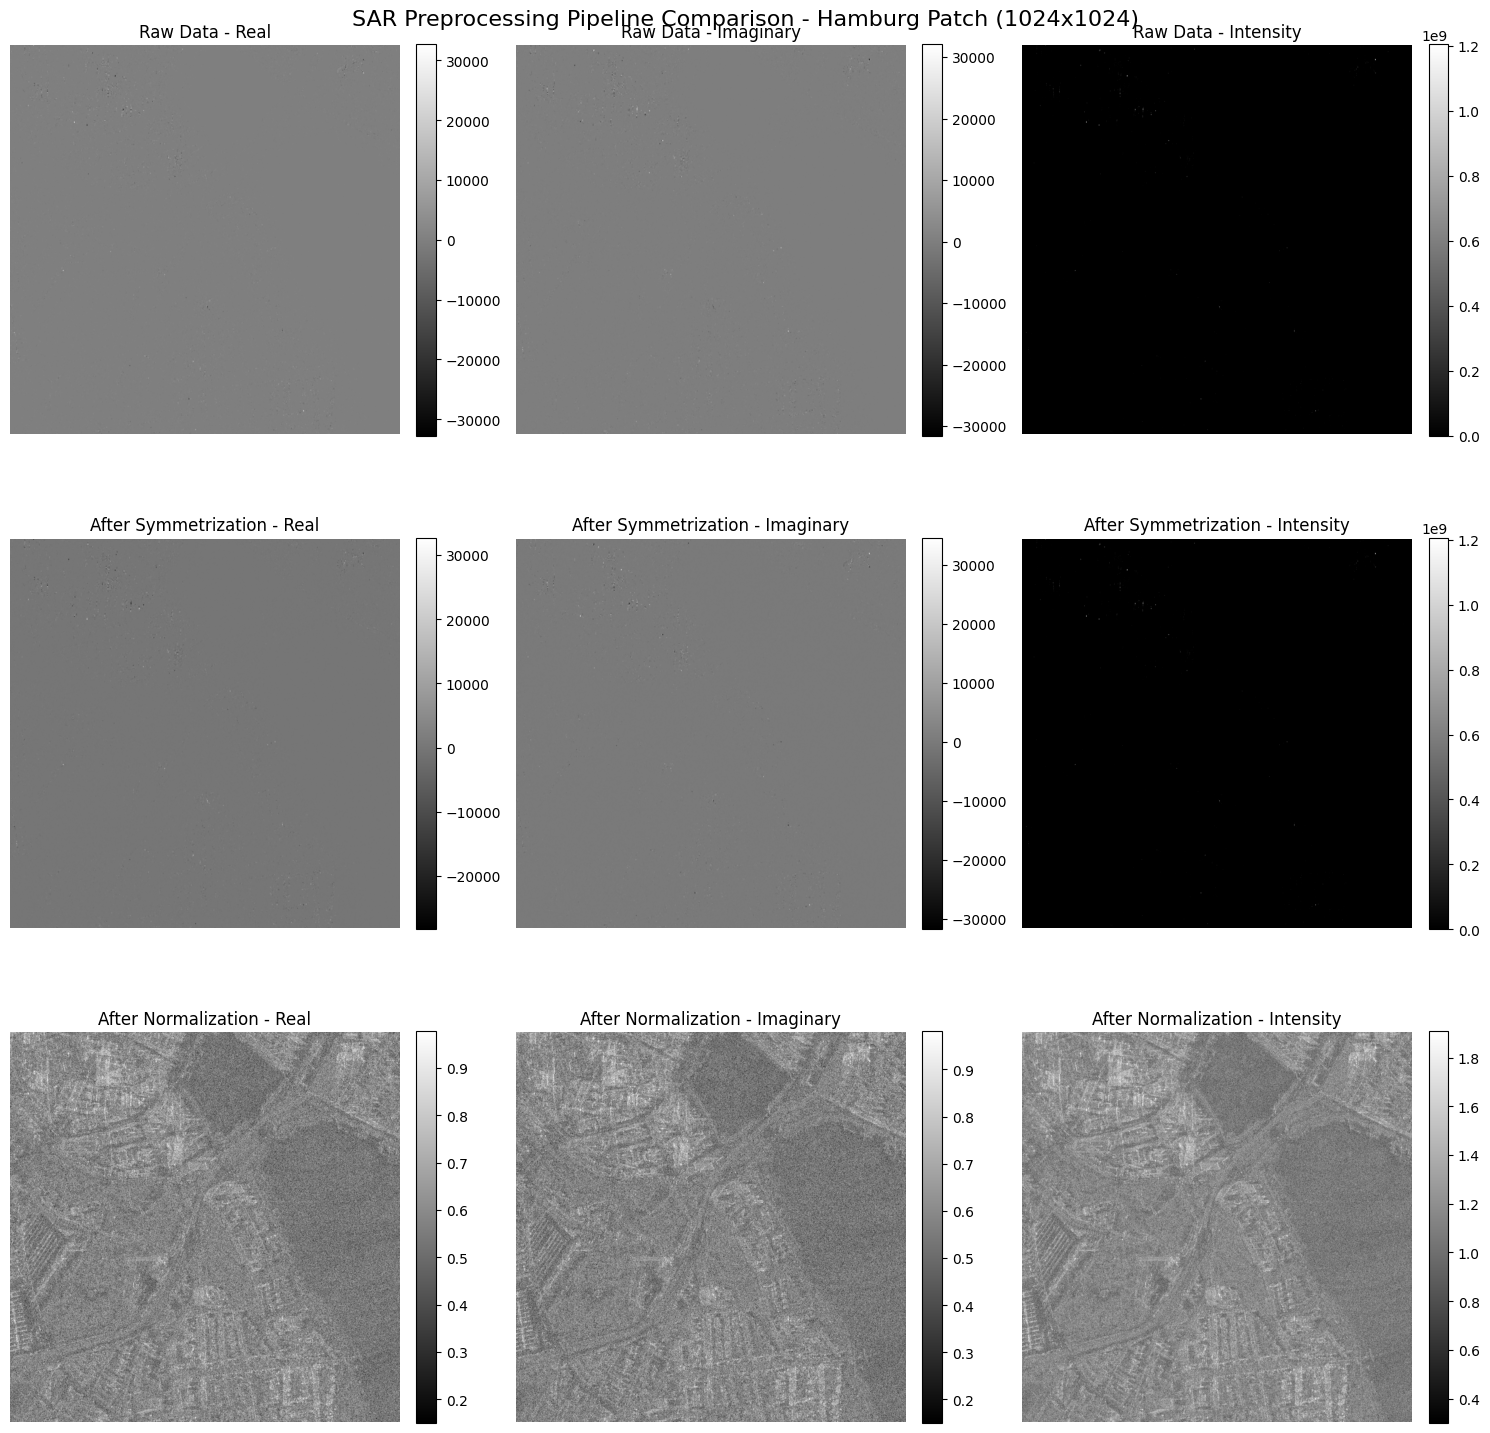

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Store all patches and titles
patches = [raw_patch, symmetrized_patch, normalized_patch]
titles = ["Raw Data", "After Symmetrization", "After Normalization"]

for i, (patch, title) in enumerate(zip(patches, titles)):
    # Real component
    im1 = axes[i, 0].imshow(patch[:, :, 0], cmap="gray", aspect="equal")
    axes[i, 0].set_title(f"{title} - Real")
    axes[i, 0].axis("off")
    plt.colorbar(im1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # Imaginary component
    im2 = axes[i, 1].imshow(patch[:, :, 1], cmap="gray", aspect="equal")
    axes[i, 1].set_title(f"{title} - Imaginary")
    axes[i, 1].axis("off")
    plt.colorbar(im2, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # Intensity
    intensity = (
        np.square(patch[:, :, 0]) + np.square(patch[:, :, 1])
        if not (title == "After Normalization")
        else patch[:, :, 0] + patch[:, :, 1]
    )
    im3 = axes[i, 2].imshow(intensity, cmap="gray", aspect="equal")
    axes[i, 2].set_title(f"{title} - Intensity")
    axes[i, 2].axis("off")
    plt.colorbar(im3, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.suptitle(
    "SAR Preprocessing Pipeline Comparison - Hamburg Patch (1024x1024)",
    fontsize=16,
    y=0.98,
)
plt.show()